# CRM Sales Opportunity - V's Analysis

### Setup Environment

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import plotly.express as px
import seaborn as sns

In [2]:
dictionary = pd.read_csv('data_dictionary.csv')

accounts = pd.read_csv('accounts.csv')
products = pd.read_csv('products.csv')
sales_teams = pd.read_csv('sales_teams.csv')
sales_pipeline = pd.read_csv('sales_pipeline.csv')

### Scanning Main Datasets

In [3]:
dictionary.info()
print('\n')
accounts.info()
print('\n')
products.info()
print('\n')
sales_teams.info()
print('\n')
sales_pipeline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Table        21 non-null     object
 1   Field        21 non-null     object
 2   Description  21 non-null     object
dtypes: object(3)
memory usage: 636.0+ bytes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   account           85 non-null     object 
 1   sector            85 non-null     object 
 2   year_established  85 non-null     int64  
 3   revenue           85 non-null     float64
 4   employees         85 non-null     int64  
 5   office_location   85 non-null     object 
 6   subsidiary_of     15 non-null     object 
dtypes: float64(1), int64(2), object(4)
memory usage: 4.8+ KB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entri

In [4]:
sales_pipeline['engage_date'] = pd.to_datetime(sales_pipeline['engage_date'])
sales_pipeline['close_date'] = pd.to_datetime(sales_pipeline['close_date'])

In [5]:
# Account
print(accounts['sector'].unique())
print(accounts['office_location'].unique(), '\n\n')

# Product
print(products['series'].unique(), '\n\n')

# Sales teams
print(sales_teams['manager'].unique())
print(sales_teams['regional_office'].unique(), '\n\n')

# Sales pipeline
print(sales_pipeline['deal_stage'].unique())

['technolgy' 'medical' 'retail' 'software' 'entertainment' 'marketing'
 'telecommunications' 'finance' 'employment' 'services']
['United States' 'Kenya' 'Philipines' 'Japan' 'Italy' 'Norway' 'Korea'
 'Jordan' 'Brazil' 'Germany' 'Panama' 'Belgium' 'Romania' 'Poland' 'China'] 


['GTX' 'MG' 'GTK'] 


['Dustin Brinkmann' 'Melvin Marxen' 'Cara Losch' 'Rocco Neubert'
 'Celia Rouche' 'Summer Sewald']
['Central' 'East' 'West'] 


['Won' 'Engaging' 'Lost' 'Prospecting']


In [6]:
print(accounts.head(5), '\n')
print(products.head(5), '\n')
print(sales_teams.head(5), '\n')
print(sales_pipeline.head(5))

            account     sector  year_established  revenue  employees  \
0  Acme Corporation  technolgy              1996  1100.04       2822   
1        Betasoloin    medical              1999   251.41        495   
2          Betatech    medical              1986   647.18       1185   
3        Bioholding    medical              2012   587.34       1356   
4           Bioplex    medical              1991   326.82       1016   

  office_location subsidiary_of  
0   United States           NaN  
1   United States           NaN  
2           Kenya           NaN  
3      Philipines           NaN  
4   United States           NaN   

        product series  sales_price
0     GTX Basic    GTX          550
1       GTX Pro    GTX         4821
2    MG Special     MG           55
3   MG Advanced     MG         3393
4  GTX Plus Pro    GTX         5482 

         sales_agent           manager regional_office
0      Anna Snelling  Dustin Brinkmann         Central
1     Cecily Lampkin  Dustin Brin

In [7]:
print(sales_pipeline['close_date'].min(), ' - ', sales_pipeline['close_date'].max())

2017-03-01 00:00:00  -  2017-12-31 00:00:00


### Adding / Removing Columns

In [8]:
sales_pipeline.isna().sum()

opportunity_id       0
sales_agent          0
product              0
account           1425
deal_stage           0
engage_date        500
close_date        2089
close_value       2089
dtype: int64

In [9]:
sales_pipeline.duplicated().sum()

np.int64(0)

In [10]:
sales_pipeline = sales_pipeline.drop(sales_pipeline[
                    ((sales_pipeline['deal_stage'] == 'Engaging') & (sales_pipeline['account'].isnull())) |
                    (sales_pipeline['deal_stage'] == 'Prospecting')
                ].index)

sales_pipeline['deal_stage'].unique()

array(['Won', 'Lost', 'Engaging'], dtype=object)

In [11]:
sales_pipeline.isna().sum()/len(sales_pipeline)*100

opportunity_id    0.000000
sales_agent       0.000000
product           0.000000
account           0.000000
deal_stage        0.000000
engage_date       0.000000
close_date        6.946755
close_value       6.946755
dtype: float64

In [12]:
print('PRODUCTS')
prod_index = pd.Index(products['product'].unique())
pipeline_index = pd.Index(sales_pipeline['product'].unique())

print('Only on products:', prod_index.difference(pipeline_index))
print('Only on sales_pipeline:', pipeline_index.difference(prod_index), '\n')
print('ACCOUNTS')

acc_index = pd.Index(accounts['account'].unique())
pipeline_index = pd.Index(sales_pipeline['account'].unique())

print('Only on accounts:', acc_index.difference(pipeline_index))
print('Only on sales_pipeline:', pipeline_index.difference(acc_index))

PRODUCTS
Only on products: Index(['GTX Pro'], dtype='object')
Only on sales_pipeline: Index(['GTXPro'], dtype='object') 

ACCOUNTS
Only on accounts: Index([], dtype='object')
Only on sales_pipeline: Index([], dtype='object')


In [13]:
sales_pipeline.loc[sales_pipeline['product'] == 'GTXPro', 'product'] = 'GTX Pro'
sales_pipeline.loc[sales_pipeline['product'] == 'GTXPro']

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value


# Finding The Answers

## Products

### Price Information per Series

In [14]:
products[['series', 'sales_price']]

,series,sales_price
0,GTX,550
1,GTX,4821
2,MG,55
3,MG,3393
4,GTX,5482
5,GTX,1096
6,GTK,26768


In [15]:
products.groupby('series', as_index=False)['sales_price'].agg(
        product_count = 'count', 
        average_price = 'mean', 
        lowest_price = 'min', 
        highest_price = 'max', 
        total_product_price = 'sum'
    ).sort_values('product_count', ascending=False)

,series,product_count,average_price,lowest_price,highest_price,total_product_price
1,GTX,4,2987.25,550,5482,11949
2,MG,2,1724.00,55,3393,3448
0,GTK,1,26768.00,26768,26768,26768


## Accounts

### Count per Sector / Location / Subsidiary with Their Average Revenues

In [16]:
accounts.head(10)

,account,sector,year_established,revenue,employees,office_location,subsidiary_of
0,Acme Corporation,technolgy,1996,1100.04,2822,United States,NaN
1,Betasoloin,medical,1999,251.41,495,United States,NaN
2,Betatech,medical,1986,647.18,1185,Kenya,NaN
3,Bioholding,medical,2012,587.34,1356,Philipines,NaN
4,Bioplex,medical,1991,326.82,1016,United States,NaN
5,Blackzim,retail,2009,497.11,1588,United States,NaN
6,Bluth Company,technolgy,1993,1242.32,3027,United States,Acme Corporation
7,Bubba Gump,software,2002,987.39,2253,United States,NaN
8,Cancity,retail,2001,718.62,2448,United States,NaN
9,Cheers,entertainment,1993,4269.90,6472,United States,Massive Dynamic


In [17]:
accounts.groupby('sector', as_index=False)[['sector', 'revenue']].agg(
        sector_count = ('sector', 'count'),
        average_revenue = ('revenue', 'mean')
    ).sort_values('sector_count', ascending=False)

,sector,sector_count,average_revenue
5,retail,17,1609.162353
4,medical,12,1414.740000
8,technolgy,12,2315.044167
3,marketing,8,1633.797500
2,finance,8,2029.167500
7,software,7,4421.492857
9,telecommunications,6,2743.651667
1,entertainment,6,1610.870000
6,services,5,988.938000
0,employment,4,1526.160000


In [18]:
accounts.groupby('office_location', as_index=False)['account'].count().sort_values('account', ascending=False)

,office_location,account
14,United States,71
1,Brazil,1
0,Belgium,1
3,Germany,1
4,Italy,1
5,Japan,1
2,China,1
6,Jordan,1
7,Kenya,1
9,Norway,1


In [19]:
accounts.groupby('subsidiary_of', as_index=False)['account'].count().sort_values('account', ascending=False)

,subsidiary_of,account
0,Acme Corporation,4
5,Sonron,3
1,Bubba Gump,2
2,Golddex,2
3,Inity,2
4,Massive Dynamic,1
6,Warephase,1


In [20]:
accounts['subsidiary_of'] = accounts['subsidiary_of'].fillna('Standalone Companies')
accounts.groupby('subsidiary_of', as_index=False)['account'].count().sort_values('account', ascending=False)

,subsidiary_of,account
6,Standalone Companies,70
0,Acme Corporation,4
5,Sonron,3
1,Bubba Gump,2
3,Inity,2
2,Golddex,2
4,Massive Dynamic,1
7,Warephase,1


### Top 5 Highest and Lowest Accounts by Revenue / Employees

In [21]:
print('Top 5 Highest Accounts by Revenue')
print(accounts[['account', 'revenue', 'employees']].sort_values('revenue', ascending=False).head(5), '\n')
print('Top 5 Highest Accounts by Employees')
print(accounts[['account', 'revenue', 'employees']].sort_values('employees', ascending=False).head(5), '\n')

print('Top 5 Lowest Accounts by Revenue')
print(accounts[['account', 'revenue', 'employees']].sort_values('revenue').head(5), '\n')
print('Top 5 Lowest Accounts by Employees')
print(accounts[['account', 'revenue', 'employees']].sort_values('employees').head(5))

Top 5 Highest Accounts by Revenue
       account   revenue  employees
41    Kan-code  11698.03      34288
35    Hottechi   8170.38      16499
43       Konex   7708.38      13756
76  Xx-holding   7537.24      20293
36     Initech   6395.05      20275 

Top 5 Highest Accounts by Employees
       account   revenue  employees
41    Kan-code  11698.03      34288
76  Xx-holding   7537.24      20293
36     Initech   6395.05      20275
25   Ganjaflex   5158.71      17479
60    Scotfind   6354.87      16780 

Top 5 Lowest Accounts by Revenue
           account  revenue  employees
11          Condax     4.54          9
81  Zencorporation    40.79        142
61        Scottech    45.39        100
30         Golddex    52.50        165
80      Zathunicon    71.12        144 

Top 5 Lowest Accounts by Employees
           account  revenue  employees
11          Condax     4.54          9
13  Dalttechnology    98.79         96
61        Scottech    45.39        100
81  Zencorporation    40.79       

### Timeline of Accounts Established

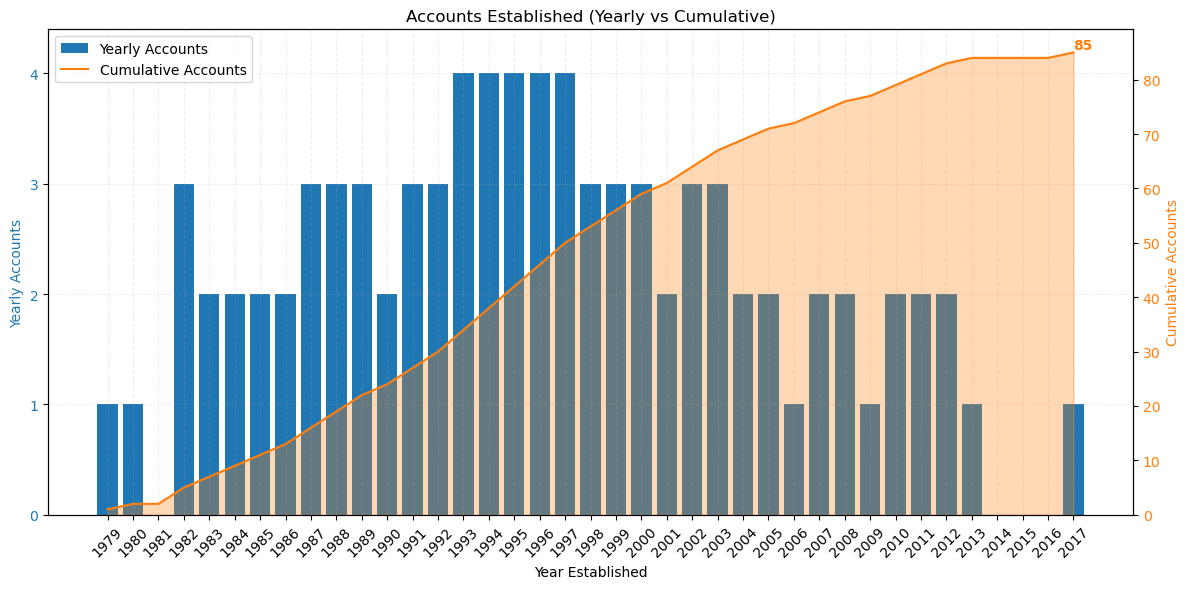

In [22]:
timeline = (
    accounts.groupby('year_established')
    .size()
    .reset_index(name='count')
)

year_range = pd.DataFrame({
    'year_established': range(
        int(timeline['year_established'].min()),
        int(timeline['year_established'].max()) + 1
    )
})

timeline = (
    year_range
    .merge(timeline, on='year_established', how='left')
    .fillna(0)
    .sort_values('year_established')
)
timeline['count'] = timeline['count'].astype(int)
timeline['cumulative'] = timeline['count'].cumsum()

# || Plot ||
x = np.arange(len(timeline))
years = timeline['year_established']
yearly = timeline['count']
cum = timeline['cumulative']

fig, ax1 = plt.subplots(figsize=(12, 6))

# || Yearly bar ||
ax1.bar(x, yearly, color='tab:blue', label='Yearly Accounts')
ax1.set_xlabel('Year Established')
ax1.set_ylabel('Yearly Accounts', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.yaxis.set_major_locator(MaxNLocator(integer=True))
ax1.set_xticks(x)
ax1.set_xticklabels(years, rotation=45)
ax1.set_ylim(0, max(yearly.max() * 1.1, 1))
ax1.margins(x=0)
ax1.grid(True, linestyle='--', alpha=0.2)

# || Cumulative ||
ax2 = ax1.twinx()
ax2.fill_between(x, cum, color='tab:orange', alpha=0.3)
ax2.plot(x, cum, color='tab:orange', label='Cumulative Accounts')
ax2.set_ylabel('Cumulative Accounts', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')
ax2.set_ylim(0, cum.max() * 1.05)

# || Final touch ||
plt.title('Accounts Established (Yearly vs Cumulative)')
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left')

last_x = x[-1]
last_y = cum.iloc[-1]
ax2.text(last_x, last_y, f'{int(last_y)}',
         ha='left', va='bottom', fontsize=10, color='tab:orange', fontweight='bold')

plt.tight_layout()
plt.show()

## Sales Pipeline

### Top Products / Accounts / Agents

In [23]:
not_lost = sales_pipeline[sales_pipeline['deal_stage']!='Lost']

In [24]:
not_lost[['sales_agent', 'product', 'account', 'close_value']].head()

,sales_agent,product,account,close_value
0,Moses Frase,GTX Plus Basic,Cancity,1054.0
1,Darcel Schlecht,GTX Pro,Isdom,4514.0
2,Darcel Schlecht,MG Special,Cancity,50.0
3,Moses Frase,GTX Basic,Codehow,588.0
4,Zane Levy,GTX Basic,Hatfan,517.0


Products

In [25]:
not_lost.groupby('product', as_index=False)['close_value'].agg(
    products_sold = 'count',
    average_closing_value = 'mean',
    highest_closing_value = 'max',
    lowest_closing_value = 'min',
    total_closing_value = 'sum'
).sort_values('products_sold', ascending=False)

,product,products_sold,average_closing_value,highest_closing_value,lowest_closing_value,total_closing_value
1,GTX Basic,915,545.642623,716.0,365.0,499263.0
6,MG Special,793,55.192938,72.0,38.0,43768.0
4,GTX Pro,729,4815.607682,6166.0,3169.0,3510578.0
5,MG Advanced,654,3388.970948,4456.0,2477.0,2216387.0
2,GTX Plus Basic,653,1080.053599,1374.0,752.0,705275.0
3,GTX Plus Pro,479,5489.876827,7356.0,3704.0,2629651.0
0,GTK 500,15,26707.466667,30288.0,23746.0,400612.0


In [26]:
not_lost.groupby('product', as_index=False)['close_value'].agg(
    products_sold = 'count',
    average_closing_value = 'mean',
    highest_closing_value = 'max',
    lowest_closing_value = 'min',
    total_closing_value = 'sum'
).sort_values('total_closing_value', ascending=False)

,product,products_sold,average_closing_value,highest_closing_value,lowest_closing_value,total_closing_value
4,GTX Pro,729,4815.607682,6166.0,3169.0,3510578.0
3,GTX Plus Pro,479,5489.876827,7356.0,3704.0,2629651.0
5,MG Advanced,654,3388.970948,4456.0,2477.0,2216387.0
2,GTX Plus Basic,653,1080.053599,1374.0,752.0,705275.0
1,GTX Basic,915,545.642623,716.0,365.0,499263.0
0,GTK 500,15,26707.466667,30288.0,23746.0,400612.0
6,MG Special,793,55.192938,72.0,38.0,43768.0


Accounts

In [27]:
not_lost.groupby('account', as_index=False)['close_value'].agg(
    products_bought = 'count',
    average_closing_value = 'mean',
    highest_closing_value = 'max',
    lowest_closing_value = 'min',
    total_closing_value = 'sum'
).sort_values('products_bought', ascending=False)

,account,products_bought,average_closing_value,highest_closing_value,lowest_closing_value,total_closing_value
40,Kan-code,115,2969.173913,25791.0,44.0,341455.0
34,Hottechi,111,1756.369369,6101.0,47.0,194957.0
42,Konex,108,2493.009259,6767.0,47.0,269245.0
11,Condax,105,1965.809524,6206.0,44.0,206410.0
55,Rangreen,75,2023.693333,5916.0,49.0,151777.0
...,...,...,...,...,...,...
18,Donware,30,1887.900000,6177.0,47.0,56637.0
6,Bluth Company,28,2032.250000,5621.0,51.0,56903.0
69,The New York Inquirer,28,2737.000000,6228.0,41.0,76636.0
38,Iselectrics,25,2901.720000,6263.0,48.0,72543.0


In [28]:
not_lost.groupby('account', as_index=False)['close_value'].agg(
    products_bought = 'count',
    average_closing_value = 'mean',
    highest_closing_value = 'max',
    lowest_closing_value = 'min',
    total_closing_value = 'sum'
).sort_values('total_closing_value', ascending=False)

,account,products_bought,average_closing_value,highest_closing_value,lowest_closing_value,total_closing_value
40,Kan-code,115,2969.173913,25791.0,44.0,341455.0
42,Konex,108,2493.009259,6767.0,47.0,269245.0
11,Condax,105,1965.809524,6206.0,44.0,206410.0
9,Cheers,57,3474.035088,29166.0,44.0,198020.0
34,Hottechi,111,1756.369369,6101.0,47.0,194957.0
...,...,...,...,...,...,...
67,Sumace,23,2604.565217,5480.0,51.0,59905.0
6,Bluth Company,28,2032.250000,5621.0,51.0,56903.0
18,Donware,30,1887.900000,6177.0,47.0,56637.0
79,Zathunicon,34,1635.764706,5343.0,42.0,55616.0


Agents

In [29]:
not_lost.groupby('sales_agent', as_index=False)['close_value'].agg(
    products_sold = 'count',
    average_closing_value = 'mean',
    highest_closing_value = 'max',
    lowest_closing_value = 'min',
    total_closing_value = 'sum'
).sort_values('products_sold', ascending=False)

,sales_agent,products_sold,average_closing_value,highest_closing_value,lowest_closing_value,total_closing_value
6,Darcel Schlecht,349,3304.338109,6360.0,47.0,1153214.0
26,Vicki Laflamme,221,2164.687783,6206.0,45.0,478396.0
15,Kary Hendrixson,209,2173.674641,6555.0,44.0,454298.0
0,Anna Snelling,208,1322.384615,6659.0,44.0,275056.0
25,Versie Hillebrand,176,1066.437500,6282.0,41.0,187693.0
14,Kami Bicknell,174,1818.712644,6304.0,42.0,316456.0
13,Jonathan Berthelot,171,1666.000000,6096.0,49.0,284886.0
2,Cassey Cress,163,2763.736196,6509.0,44.0,450489.0
29,Zane Levy,161,2671.229814,6637.0,46.0,430068.0
7,Donn Cantrell,158,2821.898734,6540.0,49.0,445860.0


In [30]:
not_lost.groupby('sales_agent', as_index=False)['close_value'].agg(
    products_bought = 'count',
    average_closing_value = 'mean',
    highest_closing_value = 'max',
    lowest_closing_value = 'min',
    total_closing_value = 'sum'
).sort_values('total_closing_value', ascending=False)

,sales_agent,products_bought,average_closing_value,highest_closing_value,lowest_closing_value,total_closing_value
6,Darcel Schlecht,349,3304.338109,6360.0,47.0,1153214.0
26,Vicki Laflamme,221,2164.687783,6206.0,45.0,478396.0
15,Kary Hendrixson,209,2173.674641,6555.0,44.0,454298.0
2,Cassey Cress,163,2763.736196,6509.0,44.0,450489.0
7,Donn Cantrell,158,2821.898734,6540.0,49.0,445860.0
22,Reed Clapper,155,2827.974194,6767.0,49.0,438336.0
29,Zane Levy,161,2671.229814,6637.0,46.0,430068.0
4,Corliss Cosme,150,2806.906667,6372.0,41.0,421036.0
12,James Ascencio,135,3063.207407,7356.0,44.0,413533.0
5,Daniell Hammack,114,3194.991228,6920.0,51.0,364229.0


### Products Close Value Charts

In [31]:
prod_sales = not_lost.merge(products[['product', 'sales_price']], on='product', how='outer')
prod_sales = prod_sales[['product', 'close_date', 'close_value', 'sales_price']]
prod_sales

,product,close_date,close_value,sales_price
0,GTK 500,2017-03-09,25897.0,26768
1,GTK 500,NaT,NaN,26768
2,GTK 500,2017-06-07,30288.0,26768
3,GTK 500,NaT,NaN,26768
4,GTK 500,2017-06-27,29617.0,26768
...,...,...,...,...
4734,MG Special,2017-12-28,58.0,55
4735,MG Special,NaT,NaN,55
4736,MG Special,2017-12-28,50.0,55
4737,MG Special,2017-12-28,61.0,55


          product  total_revenue  total_sold  above_suggested  \
1       GTX Basic       499263.0         915              436   
6      MG Special        43768.0         793              370   
4         GTX Pro      3510578.0         729              366   
5     MG Advanced      2216387.0         654              322   
2  GTX Plus Basic       705275.0         653              297   
3    GTX Plus Pro      2629651.0         479              243   
0         GTK 500       400612.0          15                6   

   below_suggested  equals_suggested  max_price   max_date  min_price  \
1              470                 9      716.0 2017-12-18      365.0   
6              371                52       72.0 2017-09-21       38.0   
4              363                 0     6166.0 2017-12-06     3169.0   
5              331                 1     4456.0 2017-11-26     2477.0   
2              353                 3     1374.0 2017-12-17      752.0   
3              236                 0     

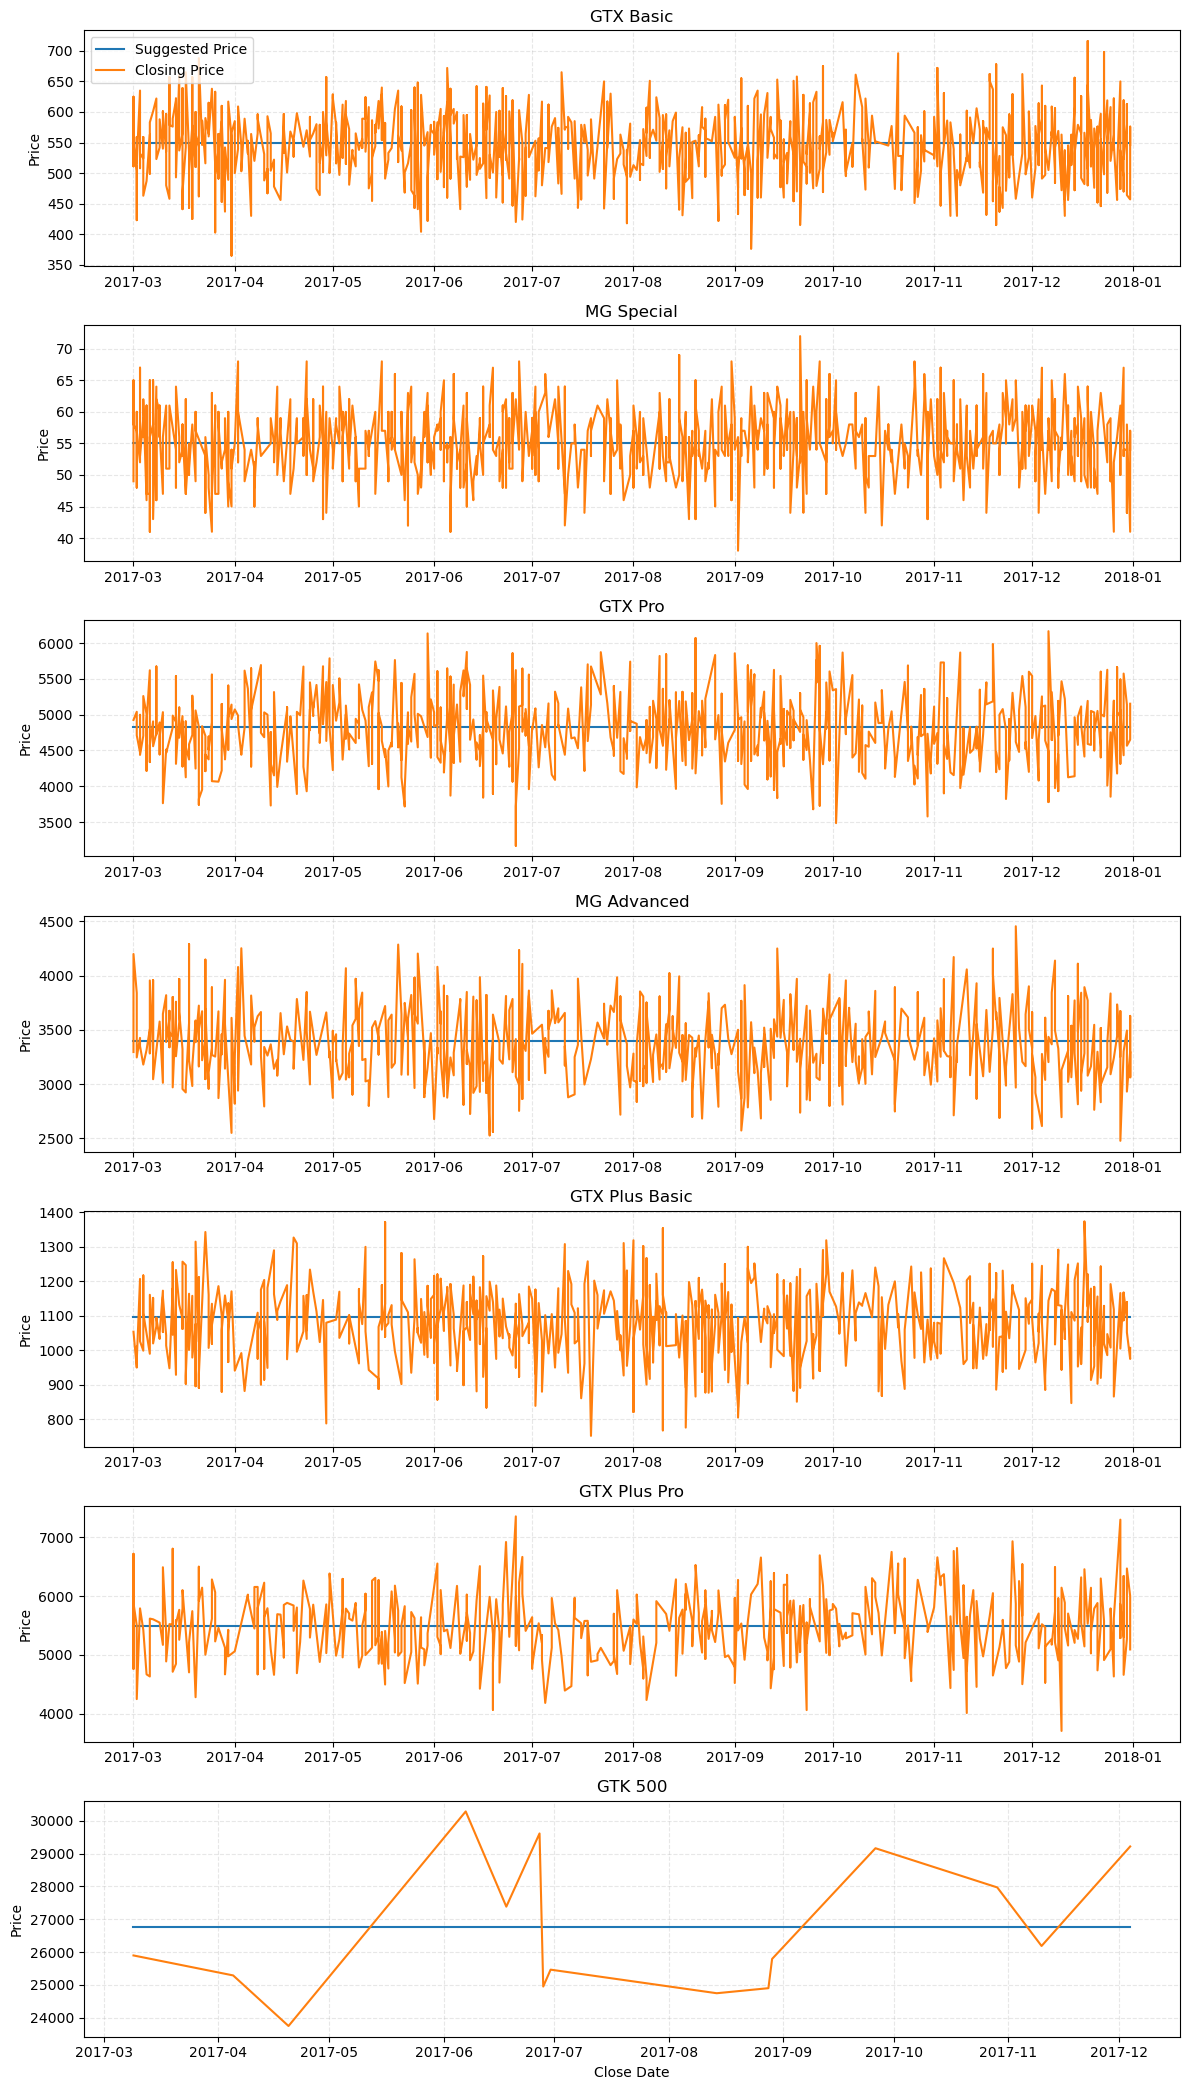

In [32]:
p_name = prod_sales['product'].unique()

summary_list = []

for product in p_name:
    data = prod_sales[prod_sales['product'] == product].dropna(subset=['close_value', 'sales_price'])
    if data.empty:
        continue
    
    total_revenue = (data['close_value']).sum()
    total_sold = len(data)
    above_suggested = (data['close_value'] > data['sales_price']).sum()
    below_suggested = (data['close_value'] < data['sales_price']).sum()
    equals_suggested = (data['close_value'] == data['sales_price']).sum()
    
    max_row = data.loc[data['close_value'].idxmax()]
    min_row = data.loc[data['close_value'].idxmin()]
    
    summary_list.append({
        'product': product,
        'total_revenue': total_revenue,
        'total_sold': total_sold,
        'above_suggested': above_suggested,
        'below_suggested': below_suggested,
        'equals_suggested': equals_suggested,
        'max_price': max_row['close_value'],
        'max_date': max_row['close_date'],
        'min_price': min_row['close_value'],
        'min_date': min_row['close_date']
    })

summary_df = pd.DataFrame(summary_list)
summary_df = summary_df.sort_values('total_sold', ascending=False)
print(summary_df)


# || Charts ||
p_name = summary_df['product'].tolist()

fig, axes = plt.subplots(len(p_name), 1, figsize=(12, 3*len(p_name)))

for i, product in enumerate(p_name):
    ax = axes[i]
    data = prod_sales[prod_sales['product'] == product].sort_values('close_date')
    
    ax.plot(data['close_date'], data['sales_price'], label='Suggested Price', color='tab:blue')
    ax.plot(data['close_date'], data['close_value'], label='Closing Price', color='tab:orange')
    ax.set_title(product)
    ax.set_ylabel('Price')
    ax.grid(True, linestyle='--', alpha=0.3)
    
    if i == 0:
        ax.legend(loc='upper left')

plt.xlabel('Close Date')
plt.tight_layout()
plt.show()

In [33]:
summary_df

,product,total_revenue,total_sold,above_suggested,below_suggested,equals_suggested,max_price,max_date,min_price,min_date
1,GTX Basic,499263.0,915,436,470,9,716.0,2017-12-18,365.0,2017-03-31
6,MG Special,43768.0,793,370,371,52,72.0,2017-09-21,38.0,2017-09-02
4,GTX Pro,3510578.0,729,366,363,0,6166.0,2017-12-06,3169.0,2017-06-26
5,MG Advanced,2216387.0,654,322,331,1,4456.0,2017-11-26,2477.0,2017-12-28
2,GTX Plus Basic,705275.0,653,297,353,3,1374.0,2017-12-17,752.0,2017-07-19
3,GTX Plus Pro,2629651.0,479,243,236,0,7356.0,2017-06-26,3704.0,2017-12-10
0,GTK 500,400612.0,15,6,9,0,30288.0,2017-06-07,23746.0,2017-04-20


### Deal Stage Comparison by Product & Account

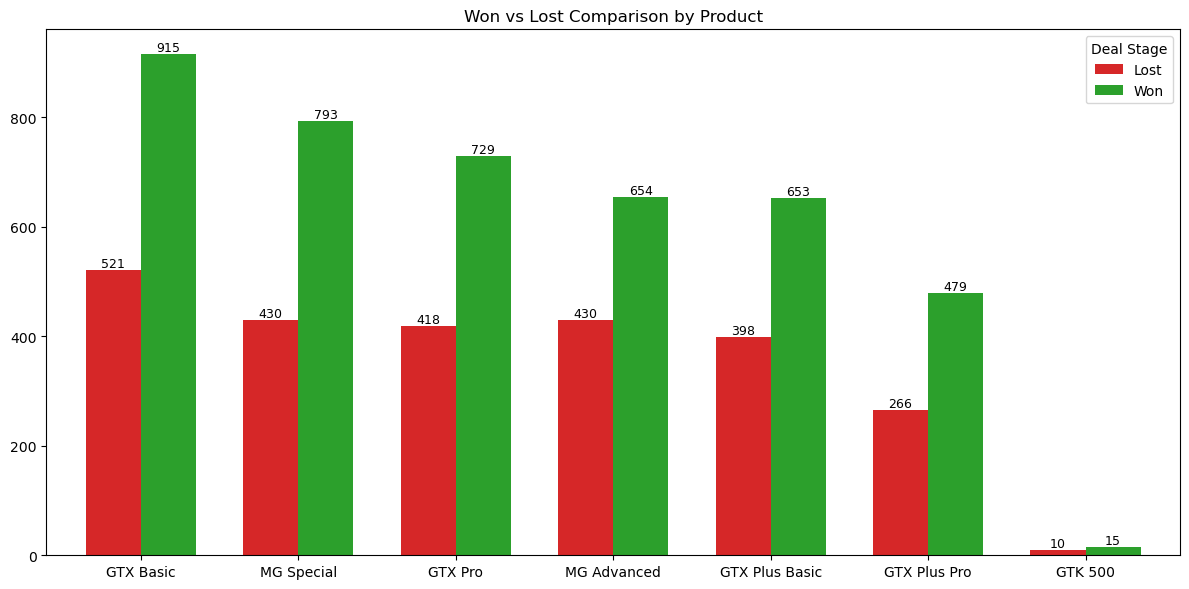

In [34]:
prod_stage = sales_pipeline[
    sales_pipeline['deal_stage'].isin(['Won', 'Lost'])
].groupby(['product', 'deal_stage'])['close_value'].count().reset_index()

prod_stage = prod_stage.rename(columns={'close_value': 'deal_count'})
prod_stage_pivot = prod_stage.pivot(index='product', columns='deal_stage', values='deal_count').fillna(0)

prod_stage_pivot = prod_stage_pivot.sort_values(by='Won', ascending=False)

ax = prod_stage_pivot.plot(
    kind='bar',
    figsize=(12, 6),
    width=0.7,
    color=['tab:red', 'tab:green']
)

plt.title('Won vs Lost Comparison by Product')
plt.ylabel('')
plt.xlabel('')
plt.legend(title='Deal Stage')
plt.xticks(rotation=0)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            str(int(height)),
            (p.get_x() + p.get_width() / 2, height),
            ha='center', va='bottom', fontsize=9
        )

plt.tight_layout()
plt.show()

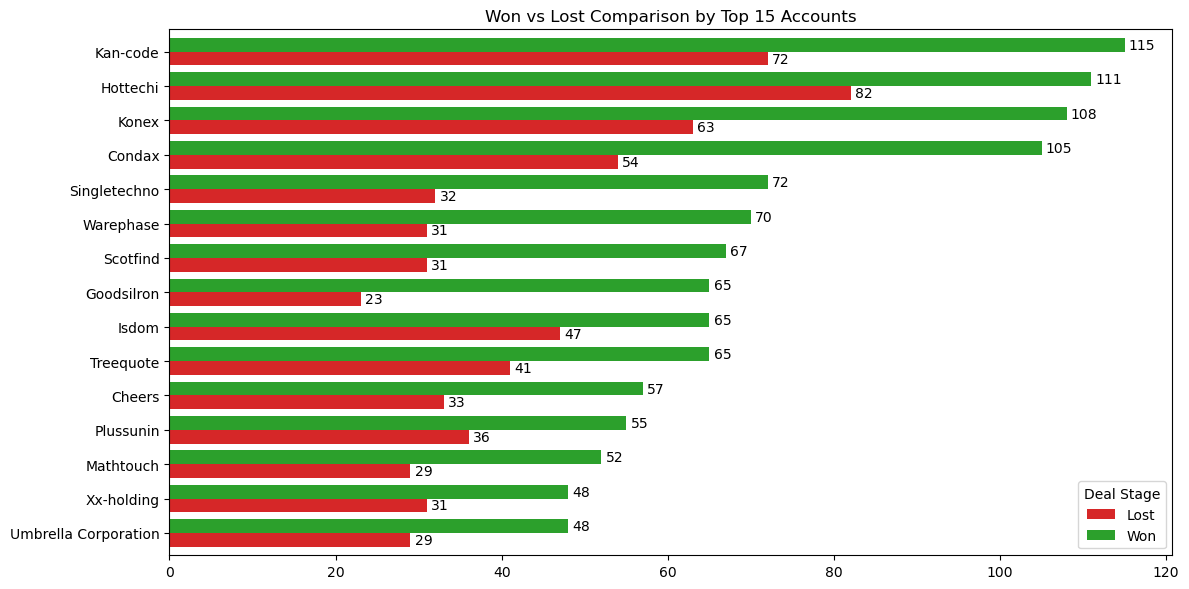

In [35]:
top_accounts = sales_pipeline.groupby('account')['close_value'].sum().nlargest(15).index

acc_stage = sales_pipeline[
    (sales_pipeline['account'].isin(top_accounts)) &
    (sales_pipeline['deal_stage'].isin(['Won', 'Lost']))
].groupby(['account', 'deal_stage'])['close_value'].count().reset_index()

acc_stage = acc_stage.rename(columns={'close_value': 'deal_count'})
acc_stage_pivot = acc_stage.pivot(index='account', columns='deal_stage', values='deal_count').fillna(0)
acc_stage_pivot = acc_stage_pivot.sort_values(by='Won', ascending=True)

ax = acc_stage_pivot.plot(
    kind='barh',
    figsize=(12, 6),
    width=0.8,
    color=['tab:red', 'tab:green']
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3)

plt.title('Won vs Lost Comparison by Top 15 Accounts')
plt.xlabel('')
plt.ylabel('')
plt.legend(title='Deal Stage')
plt.tight_layout()
plt.show()

### Left Behind Sales Agents + Team's Performance Comparison (Managerial / Regional)

In [36]:
sales_performance = sales_pipeline.merge(sales_teams, on='sales_agent', how='outer')

# || Pipeline ||
pipeline_perf = (
    sales_performance
    .groupby(['sales_agent', 'deal_stage'])
    .agg(
        total_deals=('opportunity_id', 'count'),
        total_value=('close_value', 'sum')
    )
    .reset_index()
)

print(pipeline_perf.head(10), '\n')


# || Team performance: Managerial ||
team_perf = (
    sales_performance
    .groupby(['sales_agent'])
    .agg(
        total_value=('close_value','sum'),
        total_deals=('opportunity_id','count'),
        closed_won=('deal_stage', lambda x: (x=='Won').sum()),
        closed_lost=('deal_stage', lambda x: (x=='Lost').sum())
    )
    .reset_index()
)

team_perf['win_rate'] = team_perf['closed_won'] / (team_perf['closed_won'] + team_perf['closed_lost'])

print(team_perf.head(), '\n')

team_perf = team_perf.merge(
    sales_teams[['sales_agent', 'manager']], 
    on='sales_agent', 
    how='left'
)

# || Agreggation ||
manager_perf = (
    team_perf
    .groupby('manager')
    .agg(
        total_value=('total_value','sum'),
        total_deals=('total_deals','sum'),
        closed_won=('closed_won','sum'),
        closed_lost=('closed_lost','sum'),
        avg_deal_size=('total_value','mean')
    )
    .reset_index()
)

manager_perf['win_rate'] = manager_perf['closed_won'] / (manager_perf['closed_won'] + manager_perf['closed_lost'])

print(manager_perf)

      sales_agent deal_stage  total_deals  total_value
0   Anna Snelling   Engaging           19          0.0
1   Anna Snelling       Lost          128          0.0
2   Anna Snelling        Won          208     275056.0
3       Boris Faz   Engaging           18          0.0
4       Boris Faz       Lost           52          0.0
5       Boris Faz        Won          101     261631.0
6    Cassey Cress   Engaging           29          0.0
7    Cassey Cress       Lost           98          0.0
8    Cassey Cress        Won          163     450489.0
9  Cecily Lampkin   Engaging            3          0.0 

      sales_agent  total_value  total_deals  closed_won  closed_lost  win_rate
0   Anna Snelling     275056.0          355         208          128  0.619048
1       Boris Faz     261631.0          171         101           52  0.660131
2        Carl Lin          0.0            0           0            0       NaN
3  Carol Thompson          0.0            0           0            0       Na

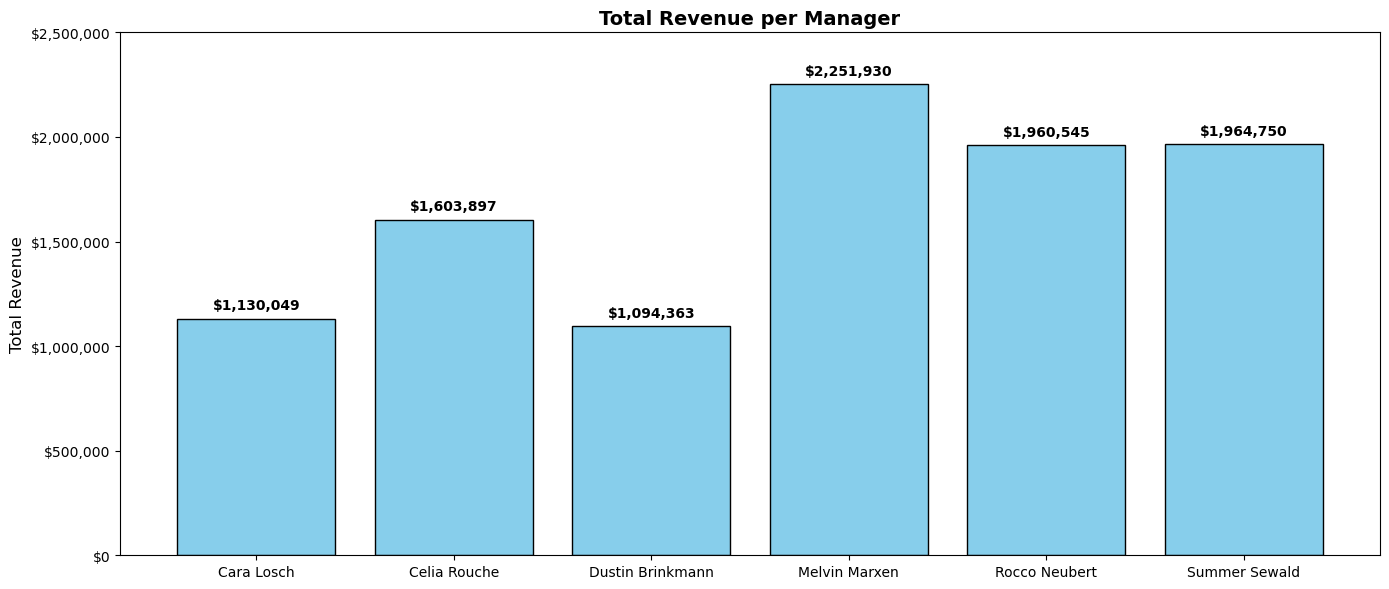

In [37]:
max_val = manager_perf['total_value'].max()

step = 500000
yticks = np.arange(0, max_val + step, step)

plt.figure(figsize=(14,6))
plt.bar(
    manager_perf['manager'],
    manager_perf['total_value'],
    color='skyblue',
    edgecolor='black'
)

plt.title('Total Revenue per Manager', fontsize=14, weight='bold')
plt.xlabel('')
plt.ylabel('Total Revenue', fontsize=12)
plt.yticks(yticks, [f'${y:,.0f}' for y in yticks])

for i, val in enumerate(manager_perf['total_value']):
    plt.text(i, val + (0.02 * max_val), 
             f'${val:,.0f}', ha='center', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

In [38]:
team_perf['win_rate'] = team_perf['win_rate'].fillna(0)
team_perf.sort_values('win_rate').head(10)

,sales_agent,total_value,total_deals,closed_won,closed_lost,win_rate,manager
3,Carol Thompson,0.0,0,0,0,0.000000,Celia Rouche
2,Carl Lin,0.0,0,0,0,0.000000,Summer Sewald
11,Elizabeth Anderson,0.0,0,0,0,0.000000,Cara Losch
23,Mei-Mei Johns,0.0,0,0,0,0.000000,Melvin Marxen
25,Natalya Ivanova,0.0,0,0,0,0.000000,Rocco Neubert
19,Lajuana Vencill,194632.0,245,127,104,0.549784,Dustin Brinkmann
20,Markita Hansen,328792.0,254,130,97,0.572687,Celia Rouche
9,Donn Cantrell,445860.0,275,158,117,0.574545,Rocco Neubert
13,Gladys Colclough,345674.0,244,135,97,0.581897,Melvin Marxen
26,Niesha Huffines,176961.0,190,105,70,0.600000,Melvin Marxen


  regional_office  total_value  total_deals  closed_won  closed_lost  \
0         Central    3346293.0         2738        1629          975   
1            East    3090594.0         1995        1171          687   
2            West    3568647.0         2479        1438          811   

   avg_deal_size  win_rate  
0  304208.454545  0.625576  
1  257549.500000  0.630248  
2  297387.250000  0.639395  


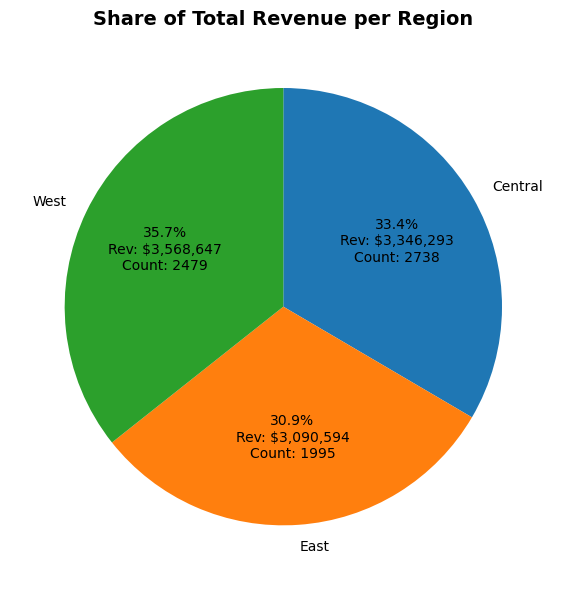

In [39]:
# || Regional ||
regional_perf = (
    team_perf
    .merge(sales_teams[['sales_agent','regional_office']], on='sales_agent', how='left')
    .groupby('regional_office')
    .agg(
        total_value=('total_value','sum'),
        total_deals=('total_deals','sum'),
        closed_won=('closed_won','sum'),
        closed_lost=('closed_lost','sum'),
        avg_deal_size=('total_value','mean')
    )
    .reset_index()
)

regional_perf['win_rate'] = regional_perf['closed_won'] / (regional_perf['closed_won'] + regional_perf['closed_lost'])

print(regional_perf)

fig, ax = plt.subplots(figsize=(6,6))

def autopct_format(values_revenue, values_deals):
    def inner_autopct(pct):
        idx = inner_autopct.index
        revenue = values_revenue[idx]
        deals   = values_deals[idx]
        inner_autopct.index += 1
        return f'{pct:.1f}%\nRev: ${revenue:,.0f}\nCount: {deals}'
    inner_autopct.index = 0
    return inner_autopct

ax.pie(
    regional_perf['total_value'],
    labels=regional_perf['regional_office'],
    autopct=autopct_format(regional_perf['total_value'].values,
                           regional_perf['total_deals'].values),
    startangle=90,
    counterclock=False
)

ax.set_title('Share of Total Revenue per Region', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

### Quarterly Trends

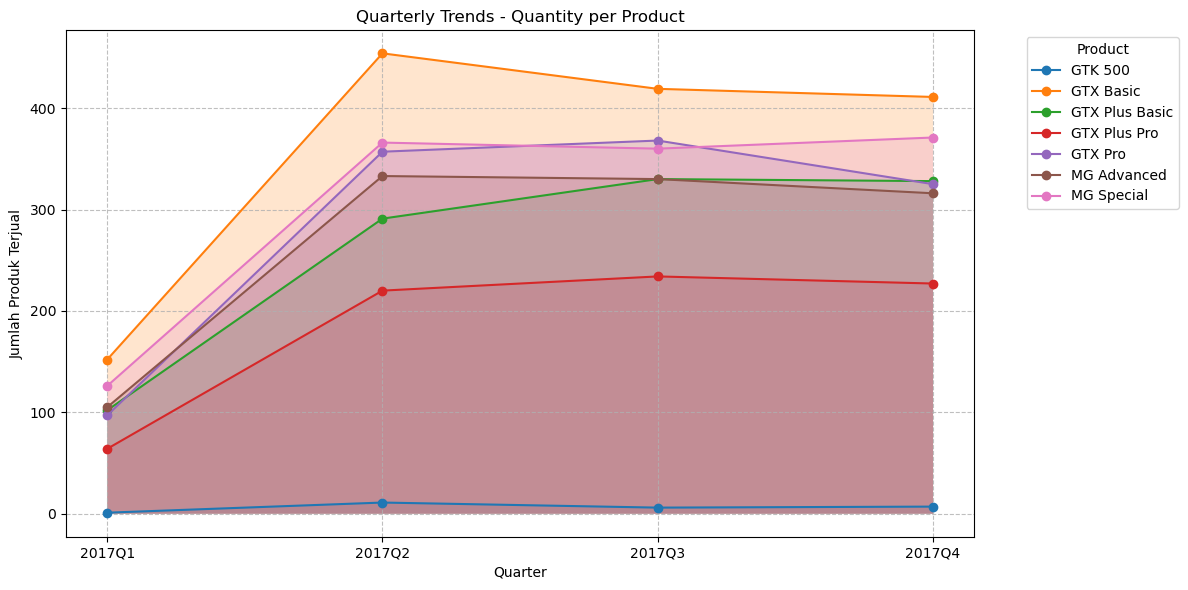

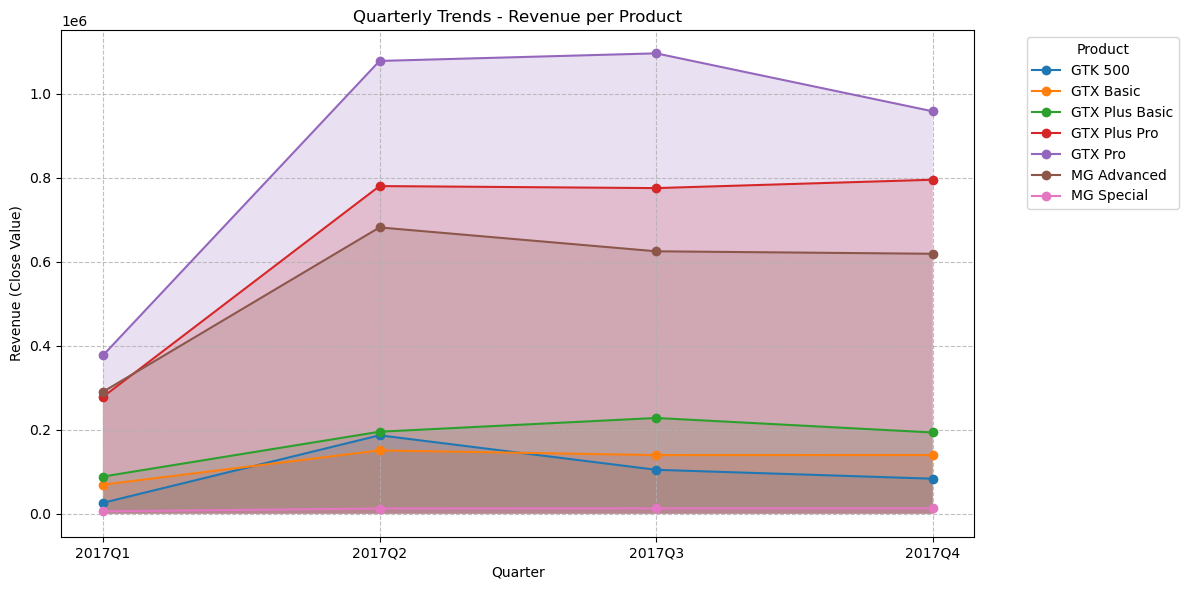

In [40]:
sales_pipeline['quarter'] = sales_pipeline['close_date'].dt.to_period('Q')

quarter = sales_pipeline.groupby(['quarter', 'product']).agg(
    deal_count=('product', 'count'),
    revenue=('close_value', 'sum')
).reset_index()

df_qty = quarter.pivot(index='quarter', columns='product', values='deal_count').fillna(0)
df_rev = quarter.pivot(index='quarter', columns='product', values='revenue').fillna(0)

# || PLOT QUANTITY ||
plt.figure(figsize=(12, 6))
for col in df_qty.columns:
    x = df_qty.index.astype(str)
    y = df_qty[col]
    plt.plot(x, y, marker='o', label=col)
    plt.fill_between(x, y, alpha=0.2)

plt.title('Quarterly Trends - Quantity per Product')
plt.xlabel('Quarter')
plt.ylabel('Jumlah Produk Terjual')
plt.legend(title='Product', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.8)
plt.tight_layout()
plt.show()

# || PLOT REVENUE ||
plt.figure(figsize=(12, 6))
for col in df_rev.columns:
    x = df_rev.index.astype(str)
    y = df_rev[col]
    plt.plot(x, y, marker='o', label=col)
    plt.fill_between(x, y, alpha=0.2)

plt.title('Quarterly Trends - Revenue per Product')
plt.xlabel('Quarter')
plt.ylabel('Revenue (Close Value)')
plt.legend(title='Product', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.8)
plt.tight_layout()
plt.show()

### Correlation of the time between Engage Date and Close Date on the Deal Stage

In [41]:
sales_pipeline['duration_days'] = (
    sales_pipeline['close_date'] - sales_pipeline['engage_date']
).dt.days

In [42]:
sales_pipeline.head()

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,quarter,duration_days
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0,2017Q1,132.0
1,Z063OYW0,Darcel Schlecht,GTX Pro,Isdom,Won,2016-10-25,2017-03-11,4514.0,2017Q1,137.0
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0,2017Q1,133.0
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.0,2017Q1,135.0
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0,2017Q1,128.0


C:\Users\Valen\AppData\Local\Temp\ipykernel_28620\1407545450.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


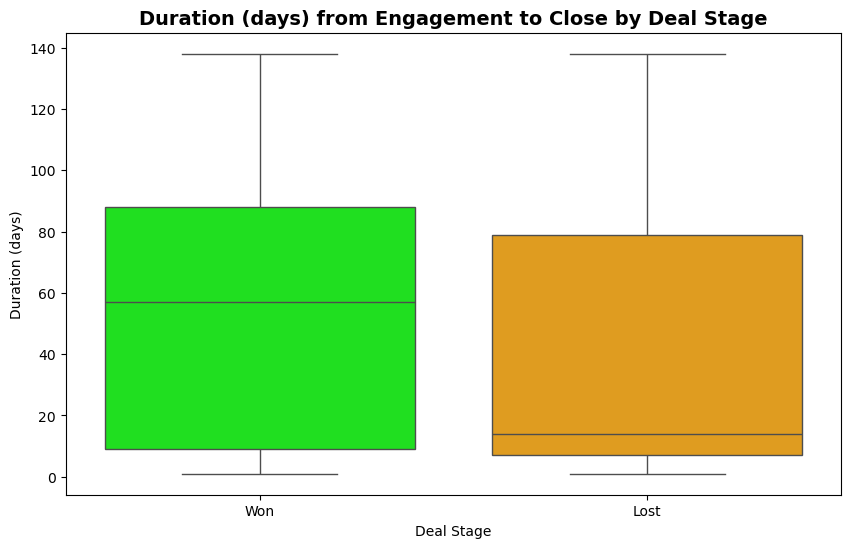

In [43]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=sales_pipeline[sales_pipeline['deal_stage'].isin(['Won','Lost'])],
    x='deal_stage',
    y='duration_days',
    palette={'Won': 'lime', 'Lost': 'orange'}
)
plt.title('Duration (days) from Engagement to Close by Deal Stage', fontsize=14, weight='bold')
plt.xlabel('Deal Stage')
plt.ylabel('Duration (days)')
plt.show()

In [44]:
duration_stats = (
    sales_pipeline[sales_pipeline['deal_stage'].isin(['Won','Lost'])]
    .groupby('deal_stage')['duration_days']
    .agg(['mean','median','std','count'])
    .reset_index()
)
print(duration_stats)

  deal_stage       mean  median        std  count
0       Lost  41.479175    14.0  40.041176   2473
1        Won  51.781973    57.0  41.171603   4238


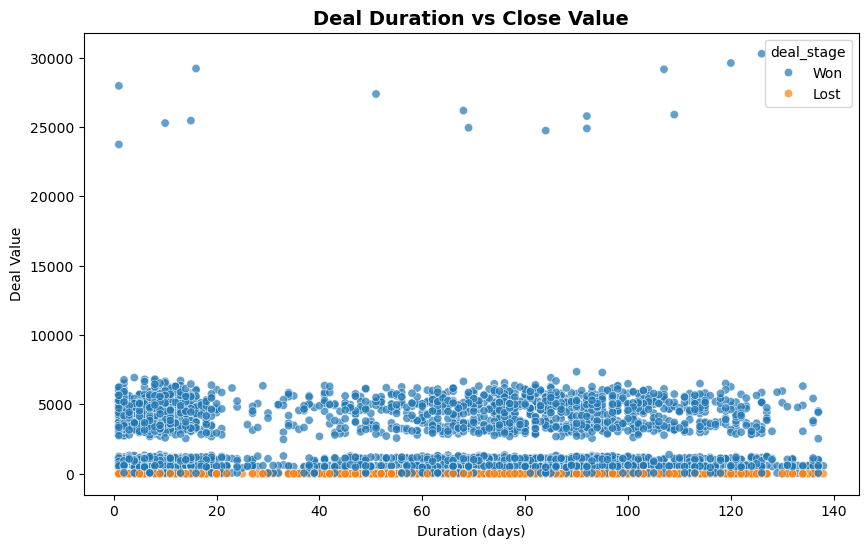

In [45]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=sales_pipeline[sales_pipeline['deal_stage'].isin(['Won','Lost'])],
    x='duration_days',
    y='close_value',
    hue='deal_stage',
    alpha=0.7
)
plt.title('Deal Duration vs Close Value', fontsize=14, weight='bold')
plt.xlabel('Duration (days)')
plt.ylabel('Deal Value')
plt.show()

In [46]:
sales_pipeline.loc[
    (sales_pipeline['deal_stage'] == 'Won') &
    (sales_pipeline['close_value'] > 20000) &
    (sales_pipeline['duration_days'] <= 20)
].sort_values('duration_days')

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,quarter,duration_days
2559,OUIK8VX3,Elease Gluck,GTK 500,Lexiqvolax,Won,2017-04-19,2017-04-20,23746.0,2017Q2,1.0
7848,H3K2E35I,Elease Gluck,GTK 500,Cheers,Won,2017-10-28,2017-10-29,27971.0,2017Q4,1.0
1825,JXUXBANJ,Rosalina Dieter,GTK 500,Y-corporation,Won,2017-03-26,2017-04-05,25288.0,2017Q2,10.0
3925,6X4EEUGA,Elease Gluck,GTK 500,Cheers,Won,2017-06-15,2017-06-30,25464.0,2017Q2,15.0
8078,GB6C2UK5,Elease Gluck,GTK 500,Xx-holding,Won,2017-11-18,2017-12-04,29220.0,2017Q4,16.0


### Deal Stage Stuck on Engaging

In [47]:
sales_pipeline[sales_pipeline['deal_stage']=='Engaging']

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,quarter,duration_days
25,UP409DSB,Maureen Marcano,MG Advanced,Ganjaflex,Engaging,2016-11-10,NaT,NaN,NaT,NaN
64,0DRC1U9Q,Maureen Marcano,GTX Basic,Green-Plus,Engaging,2016-11-20,NaT,NaN,NaT,NaN
79,M7I5O9YU,Corliss Cosme,GTX Basic,Cheers,Engaging,2016-11-23,NaT,NaN,NaT,NaN
85,VDIU10RV,Markita Hansen,MG Special,Lexiqvolax,Engaging,2016-11-23,NaT,NaN,NaT,NaN
89,579LZ3F9,Daniell Hammack,GTX Plus Basic,J-Texon,Engaging,2016-11-24,NaT,NaN,NaT,NaN
...,...,...,...,...,...,...,...,...,...,...
8249,K9KGXL2E,Markita Hansen,MG Advanced,Lexiqvolax,Engaging,2017-12-13,NaT,NaN,NaT,NaN
8259,TOJ902PF,Daniell Hammack,GTX Plus Basic,Bioholding,Engaging,2017-12-15,NaT,NaN,NaT,NaN
8262,J5BCAQ1Z,Zane Levy,GTX Basic,Bioplex,Engaging,2017-12-15,NaT,NaN,NaT,NaN
8267,RTWE19SU,Kary Hendrixson,GTX Pro,Conecom,Engaging,2017-12-17,NaT,NaN,NaT,NaN


In [48]:
funnel_data = sales_pipeline['deal_stage'].value_counts().reset_index()
funnel_data.columns = ['stage', 'count']

stage_order = ['Engaging', 'Lost', 'Won']
funnel_data['stage'] = pd.Categorical(funnel_data['stage'], categories=stage_order, ordered=True)
funnel_data = funnel_data.sort_values('stage')

fig = px.funnel(
    funnel_data,
    x='count',
    y='stage',
    labels={'stage': ''},
    title='CRM Sales Opportunities Current Status Deal',
    color='stage'
)
fig.show()